## OECD 삶의 만족도 데이터와 IMF 1인당 GDP 데이터에 대한 선형회귀 모델

Python 3.7 이상을 요구한다.

In [ ]:
import sys
assert sys.version_info >= (3,7)

Sklearn 1.0.1 이상을 요구한다.

In [ ]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

그래프 출력에 필요한 기본 설정을 지정한다.

In [2]:
import matplotlib.pyplot as plt

plt.rc('font', size=12)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=12)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

실행 결과를 동일하게 유지하기 위해 시드 넘버를 지정한다.

In [3]:
import numpy as np

np.random.seed(42)

### 1단계: 문제정의

어느 국가의 1인당 GDP가 알려졌을 때 해당 국가의 삶의 만족도를 예측하는 모델 구현

### 2단계: 데이터 구하기

훈련 데이터로 `oecd_bli_2020.csv`, `gdp_per_capita_2020.xlsx`를 사용한다.   

📍 gdp_per_capita_2020.xlsx   
- 2020년 기준 전 세계 여러 국가의 1인당 GDP를 포함한 경제 지표   
- 컬럼
    1. country: 국가명   
    2. subject descriper: 데이터 설명   
    3. units: 단위   
    4. scale: 척도 정보   
    5. country/series-specific notes: 국가별 특이사항   
    6. 2020: 2020년의 GDP 수치   
    7. estimates start after: 추정치 시작 연도


📍 oecd_bil_2020.csv   
- OECD의 다양한 사회, 경제적 지표
- 컬럼
	1.	LOCATION – 국가 코드
	2.	Country – 국가명
	3.	INDICATOR – 지표 코드
	4.	Indicator – 지표 이름
	5.	MEASURE – 측정 코드
	6.	Measure – 측정 이름 
	7.	INEQUALITY – 불평등 코드
	8.	Inequality – 불평등 항목 
	9.	Unit Code – 단위 코드
	10.	Unit – 단위 
	11.	PowerCode Code – 파워코드 값
	12.	PowerCode – 파워코드 설명 
	13.	Reference Period Code – 참고 시기 코드 (null)
	14.	Reference Period – 참고 시기 (null)
	15.	Value – 실제 측정값
	16.	Flag Codes – 플래그 코드 (null)
	17.	Flags – 플래그 설명 (null)

### 3단계: 데이터 적재, 정제, 전처리

우리가 필요한 지표는 `Country`, `GDP per capita`, `Life satisfaction` 세가지이다.   
이 세가지 지표를 추출해내기 위해 데이터를 적절한 방법으로 정제해야 한다.   

1️⃣ `Country`는 두 파일에 공통된 컬럼으로, 두 데이터 파일을 합칠 때 기준이 되는 지표라고 생각할 수 있다. 

2️⃣ `GDP per capita`는 `gdp_per_capita_2020.xlsx` 파일에서 추출할 수 있는 컬럼으로, `2020`의 컬럼을 통해 확인할 수 있다.

3️⃣ `Life satisfaction`은 두 데이터의 컬럼에서 직접적으로 확인할 수는 없다. 하지만 `oecd_bli_2020.csv` 파일에 숨겨져 있는데, 바로 `Indicator`의 데이터 안에서 찾아볼 수 있다.   
또한 이 지표에 대한 점수는 `value`의 데이터로 확인해볼 수 있다.

먼저 데이터를 정제할 파일을 불러온다.

In [8]:
import pandas as pd

oecd_bli = pd.read_csv("oecd_bli_2020.csv")
gdp_per_capita = pd.read_excel("gdp_per_capita_2020.xlsx")

2️⃣번에 해당하는 `GDP per capita`의 데이터를 추출한다.

`gdp_per_capita_2020.xlsx` 파일에는 우리가 필요한 데이터 이외에도 다양한 데이터가 있다.

지금은 필요하지 않기 때문에 우리가 필요한 컬럼인 `Country`, `2020`을 제외한 나머지 컬럼을 삭제해준다.

In [11]:
gdp_year = 2020
gdppc_col = "GDP per capita (USD)"
lifesat_col = "Life satisfaction"

gdp_per_capita = gdp_per_capita.drop(["Subject Descriptor", "Units", "Scale", "Country/Series-specific Notes","Estimates Start After"], axis=1)
gdp_per_capita.columns = ["Country", gdppc_col]
gdp_per_capita.set_index("Country", inplace=True)

gdp_per_capita.head()

,GDP per capita (USD)
Country,
Afghanistan,499.441
Albania,4898.277
Algeria,3331.076
Angola,2021.310
Antigua and Barbuda,14158.571


3️⃣번에 해당하는 `Life satisfaction`의 데이터를 추출한다.

우리가 필요한 데이터는 `Indicator`의 컬럼 속 데이터로 위치하고 있다.   
그렇기 때문에 `Indicator`의 열을 중심으로 하여 데이터와 그에 해당하는 국가 별 `value`를 추출한다.

In [12]:
oecd_bli = oecd_bli[oecd_bli["INEQUALITY"]=="TOT"]
oecd_bli = oecd_bli.pivot(index="Country", columns="Indicator", values="Value")

oecd_bli.head()

Indicator,Air pollution,Dwellings without basic facilities,Educational attainment,Employees working very long hours,Employment rate,Feeling safe walking alone at night,Homicide rate,Household net adjusted disposable income,Household net wealth,Housing expenditure,...,Personal earnings,Quality of support network,Rooms per person,Self-reported health,Stakeholder engagement for developing regulations,Student skills,Time devoted to leisure and personal care,Voter turnout,Water quality,Years in education
Country,,,,,,,,,,,,,,,,,,,,,
Australia,5.0,NaN,81.0,13.04,73.0,63.5,1.1,32759.0,427064.0,20.0,...,49126.0,95.0,NaN,85.0,2.7,502.0,14.35,91.0,93.0,21.0
Austria,16.0,0.9,85.0,6.66,72.0,80.6,0.5,33541.0,308325.0,21.0,...,50349.0,92.0,1.6,70.0,1.3,492.0,14.55,80.0,92.0,17.0
Belgium,15.0,1.9,77.0,4.75,63.0,70.1,1.0,30364.0,386006.0,21.0,...,49675.0,91.0,2.2,74.0,2.0,503.0,15.70,89.0,84.0,19.3
Brazil,10.0,6.7,49.0,7.13,61.0,35.6,26.7,NaN,NaN,NaN,...,NaN,90.0,NaN,NaN,2.2,395.0,NaN,79.0,73.0,16.2
Canada,7.0,0.2,91.0,3.69,73.0,82.2,1.3,30854.0,423849.0,22.0,...,47622.0,93.0,2.6,88.0,2.9,523.0,14.56,68.0,91.0,17.3


In [13]:
full_country_stats = pd.merge(left=oecd_bli, right=gdp_per_capita,
                              left_index=True, right_index=True)
full_country_stats.sort_values(by=gdppc_col, inplace=True)
full_country_stats = full_country_stats[[gdppc_col, lifesat_col]]

full_country_stats.head()

,GDP per capita (USD),Life satisfaction
Country,,
South Africa,4735.747,4.7
Colombia,5207.238,6.3
Brazil,6450.451,6.4
Turkey,7715.373,5.5
Mexico,8069.104,6.5


1인당 GDP와 삶의 만족도 사이의 선형 관계를 눈으로 확인하기 위해 국가를
1인당 GDP 기준 오름차순으로 정렬시킨다.

In [15]:
full_country_stats.sort_values(by="GDP per capita (USD)", inplace=True)

- GDP가 가장 낮은 5개국

In [16]:
full_country_stats.head()

,GDP per capita (USD),Life satisfaction
Country,,
South Africa,4735.747,4.7
Colombia,5207.238,6.3
Brazil,6450.451,6.4
Turkey,7715.373,5.5
Mexico,8069.104,6.5


- GDP가 가장 높은 5개국

In [17]:
full_country_stats.tail()

,GDP per capita (USD),Life satisfaction
Country,,
United States,63051.398,6.9
Norway,67988.591,7.6
Ireland,79668.502,7.0
Switzerland,81867.462,7.5
Luxembourg,109602.322,6.9


#### 추가 설정

선형 회귀 모델을 훈련시킬 때 발생할 수 있는 과대적합 문제를 설명하기 위해
고의로 7개 국가의 데이터를 데이터 셋에서 제외시키고 훈련 시킬 때와
그렇지 않을 때를 비교한다.

제외 대상 국가는 브라질, 멕시코, 칠레, 체코, 노르웨이, 스위스, 룩셈부르크 이다.
데이터프레임에서 아래 인덱스를 이용하여 7개 국가를 제외시키고 훈련을 시킬 것이다.

In [19]:
omitted_indices = [0, 1, 6, 8, 33, 34, 35]

kept_indices = list( set(range(36)) - set(omitted_indices) )

제외된 7개 국가의 1인당 GDP와 삶의 만족도 데이터는 다음과 같다.

In [20]:
missing_data = full_country_stats.iloc[omitted_indices]

missing_data

,GDP per capita (USD),Life satisfaction
Country,,
South Africa,4735.747,4.7
Colombia,5207.238,6.3
Chile,12612.322,6.5
Hungary,15372.885,5.6
Iceland,57189.031,7.5
Denmark,58438.845,7.6
United States,63051.398,6.9


7개 국가를 제외한 국가들의 1인당 GDP와 삶의 만족도 데이터를 지정한다.

In [21]:
sample_data = full_country_stats.iloc[kept_indices]

### 5단계: 모델 선택과 훈련

#### 선형 관계 확인

아래 코드는 앞서 언급된 7개 국가의 데이터를 제외한 국가들의 1인당 GDP와
삶의 만족도 사이의 관계를 산점도로 나타낸다.
선형관계를 잘 보여주는 다음 다섯 개 국가는 빨간색 점으로 표시한다.

* 헝가리(Hungary)
* 대한민국(Korea)
* 프랑스(France)
* 호주(Australia)
* 미국(United States)

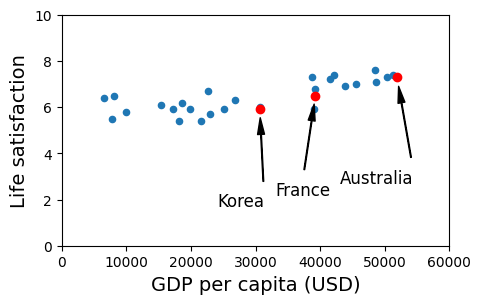

In [25]:
# 7개 국가를 제외한 국가들의 데이터 산점도
sample_data.plot(kind='scatter', x="GDP per capita (USD)", y='Life satisfaction', figsize=(5,3))
plt.axis([0, 60000, 0, 10])

# 언급된 5개 국가명과 좌표
position_text = {
    #"Hungary": (7000, 1),
    "Korea": (24000, 1.7),
    "France": (33000, 2.2),
    "Australia": (43000, 2.7),
    #"United States": (52000, 3.8),
}

# 5개 국가는 좌표를 이용하여 빨강색 점으로 표기
for country, pos_text in position_text.items():
    pos_data_x, pos_data_y = sample_data.loc[country]            # 5개 국가의 지표

    # 5개 국가명 표기
    country = "U.S." if country == "United States" else country  # 미국은 U.S. 로 표기

    # 화살표 그리기
    plt.annotate(country, xy=(pos_data_x, pos_data_y),
                 xytext=pos_text,
                 arrowprops=dict(facecolor='black', width=0.5, shrink=0.1, headwidth=5) )

    # 5개 국가 산점도 그리기: 빨강색 점
    plt.plot(pos_data_x, pos_data_y, "ro")

# x 축 제목 새롭게 지정
plt.xlabel("GDP per capita (USD)")

plt.show()

언급된 5개 국가의 1인당 GDP와 삶의 만족도를 데이터에서 직접 확인하면 다음과 같다.

In [26]:
sample_data.loc[list(position_text.keys())]

,GDP per capita (USD),Life satisfaction
Country,,
Korea,30644.427,5.9
France,39257.434,6.5
Australia,51885.466,7.3


위 산점도에 따르면 1인당 GDP와 삶의 만족도가 어느 정도 선형 관계에 있는 것처럼 보인다.

#### 선형 회귀 모델

직선처럼 y 축의 값이 x 축의 값에 선형적으로 의존하는 관계를 __선형관계__라 하며,
그런 선형관계를 함수로 구현하는 모델을 __선형 회귀 모델__(linear regression model)이라 한다.
선형 회귀 모델은 직선을 나타내는 1차 함수의 그래프로 표현되며,
직선은 절편(y축과 만나는 점)과 기울기 두 개의 값에 의해 정해진다.

예를 들어, 1인당 GDP와 삶의 만족도 사이에 다음 선형 관계가 성립하도록 하는
절편 $\theta_0$ 와 기울기 $\theta_1$ 을 구해야 한다.

$$
\text{삶의만족도} = \theta_0 + (\text{1인당GDP}) \cdot \theta_1
$$

$\theta_0$ 와 $\theta_1$ 처럼 모델 구현에 사용되는 값들을 모델의
__파라미터__<font size="2">parameter</font>라 하며,
모델의 파라미터를 찾아내는 것이 머신러닝 모델훈련의 핵심이다.

#### 사이킷런 라이브러리 활용

**사이킷런**<font size="2">scikit-learn</font> 라이브러리는 머신러닝에서 사용되는
다양한 모델을 제공한다.
선형 회귀의 경우 `LinearRegression` 클래스의 객체를 생성하여 훈련시키면
최적의 절편과 기울기를 계산해준다.

사이킷런의 모델을 지정하고 훈련시키는 과정은 다음과 같다.

**과정 1: 모델 지정**

사이킷런(sklearn) 패키지의 `linear_model` 모듈에 포함된 `LinearRegression` 클래스의 객체를 선언한다.
선언된 모델은 아직 어떤 훈련도 하지 않은 상태이다.

In [27]:
from sklearn.linear_model import LinearRegression

lin1 = LinearRegression()

**과정 2: 훈련 셋 지정**

입력 데이터 셋은 x 축에, 타깃 데이터 셋은 y 축에 해당한다.

* 입력 데이터: 1인당 GDP
* 타깃 데이터: 삶의 만족도

입력 데이터와 타깃 데이터를 2차원 어레이로 지정한다.
사이킷런의 선형 회귀 모델이 2차원 어레이 형식의 입력 데이터 셋과 타깃 데이터 셋을 요구한다.
넘파이의 `c_` 함수를 활용해서 차원을 늘려준다.

In [29]:
Xsample = np.c_[sample_data["GDP per capita (USD)"]]
ysample = np.c_[sample_data["Life satisfaction"]]

변환 전의 처음 5개 데이터는 다음과 같다.

In [31]:
np.array(sample_data["GDP per capita (USD)"][:5])

array([ 6450.451,  7715.373,  8069.104,  9972.495, 15303.544])

2차원 어레이로 변환 된 입력 데이터의 처음 5개는 다음과 같다.

In [32]:
Xsample[:5]

array([[ 6450.451],
       [ 7715.373],
       [ 8069.104],
       [ 9972.495],
       [15303.544]])

타깃 데이터 또한 마찬가지이다.

In [33]:
ysample[:5]

array([[6.4],
       [5.5],
       [6.5],
       [5.8],
       [6.1]])

**과정 3: 모델 훈련**


선형 모델의 `fit()` 메서드를 지정된 입력 데이터 셋과 타깃 터이터 셋을
인자로 사용해서 호출하면
최적의 $\theta_0$와 $\theta_1$ 파라미터를 찾는 훈련이 실행되며
훈련이 종료되면 최적의 파라미터가 업데이트된 객체 자신이 반환된다.

In [34]:
lin1.fit(Xsample, ysample)

LinearRegression()

훈련된 모델이 알아낸 최적 선형 모델의 절편과 기울기는 아래 두 속성에 저장된다.

* `intercept_[0]`: 직선의 절편
* `coef_[0]`: 직선의 기울기

In [35]:
t0, t1 = lin1.intercept_[0], lin1.coef_[0][0]

print(f"절편:\t {t0}")
print(f"기울기:\t {t1}")

절편:	 5.375355100956628
기울기:	 3.56339690854695e-05


구해진 기울기와 절편을 이용하여 산점도와 함께 직선을 그리면 다음과 같다.

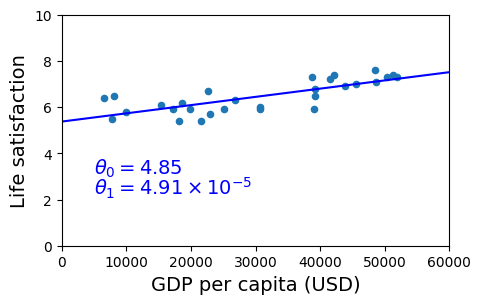

In [37]:
# 산점도
sample_data.plot(kind='scatter', x="GDP per capita (USD)", y='Life satisfaction', figsize=(5,3))
plt.xlabel("GDP per capita (USD)")
plt.axis([0, 60000, 0, 10])

# 직선 그리기
X=np.linspace(0, 60000, 1000)
plt.plot(X, t0 + t1*X, "b")

# 직선의 절편과 기울기 정보 명시
plt.text(5000, 3.1, r"$\theta_0 = 4.85$", fontsize=14, color="b")
plt.text(5000, 2.2, r"$\theta_1 = 4.91 \times 10^{-5}$", fontsize=14, color="b")

plt.show()

### 6단계: 모델 활용

한 국가의 1인당 GDP가 알려졌을 때
훈련된 모델에 포함된 $\theta_0$ 와 $\theta_1$ 을 이용하여
해당 국가의 삶의 만족도를 예측한다.
예를 들어, OECD에 속하지 않는 베트남(Vietnam)의 1인당 GDP를 이용하여
베트남 국민의 삶의 만족도를 예측한다.

In [38]:
# vietnam_gdp_per_capita_2015 = gdp_per_capita_2015.loc["Vietnam"]["GDP per capita"]

vietnam_gdp_per_capita_2015 = 2088.344

훈련된 모델의 `predict()` 메서드가 아래 식을 이용하여 삶의 만족도를 계산한다.

$$
\theta_0 + (\text{1인당GDP}) \cdot \theta_1
$$

베트남 국민의 삶의 만족도는 4.96 정도로 예측된다.

In [39]:
lin1.predict([[vietnam_gdp_per_capita_2015]])

array([[5.44977109]])

결과가 2차원 어레이로 표현됨에 주의한다.
이는 `predict()` 메서드가 여러 개의 입력값에 대해 동시에 예측값을 계산하기 때문이다.
위 코드에서는 한 개의 입력값에 대한 예측값인 `[4.95562275]`를 계산하였다.

이 예측값 또한 1차원 어레이로 표시된 이유는 머신러닝 모델은 기본적으로 하나의 입력값에 대해
여러 종류의 예측값을 계산하기 때문이다.
그리고 여기서는 삶의 만족도 한 종류의 값만 예측하기 때문이 길이가 1인 어레이가 계산되었다.
따라서 베트남의 1인당 GDP는 인덱싱으로 바로 확인된다.

In [40]:
vietnam_predicted_life_satisfaction = lin1.predict([[vietnam_gdp_per_capita_2015]])[0, 0]

print("베트남 삶의 만족도:", vietnam_predicted_life_satisfaction)

베트남 삶의 만족도: 5.449771086492453
